# **EE 413: Applied Digital Signal Processing**

##*Project: Audio Signal Classification*

**Dataset:** *Free-Spoken Digit Dataset (FSDD)*

https://github.com/Jakobovski/free-spoken-digit-dataset

**Application of course topics:**

Topic 1: Signals and System Review

Topic 2: Discrete Fourier Transform and Short Time Fourier Transform Applications

Topic 3: Wavelet Transform

##**Team Members:**

- Member 1 - ID
- Ahmad Edrees Al-Eid - 20215490
- Member 3 - ID
- Member 4 - ID




---



## 1- Data Preprocessing





### Libraries and Tools

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import hilbert
from scipy.signal import butter, filtfilt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
from sklearn.neighbors import KNeighborsClassifier
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
import ipywidgets as widgets
from matplotlib.colors import LogNorm, Normalize
from IPython.display import display
from scipy import signal, interpolate
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import librosa
import librosa.display
import librosa.feature
import librosa.util
import librosa.effects
from scipy import interpolate
from scipy.io import wavfile as wav

### Data Loading

Loading one file for testing

In [ ]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

recording_path = Path("free-spoken-digit-dataset/recordings")
audio_path = None

if audio_path is None:
    wav_files = sorted(recording_path.glob("*.wav"))
    audio_path = str(wav_files[0])

speech_sig, fs = librosa.load(audio_path, sr=None, mono=True)
N = len(speech_sig)

print("Loaded audio path:", audio_path)
print("Sampling rate (Hz):", fs)
print("Number of samples:", N)

fatal: destination path 'free-spoken-digit-dataset' already exists and is not an empty directory.
Loaded audio path: free-spoken-digit-dataset/recordings/0_george_0.wav
Sampling rate (Hz): 8000
Number of samples: 2384


Loading all .wav files

In [ ]:
wav_files = sorted(recording_path.glob("*.wav"))

speech_signals = []
labels = []
reco_names = []
sample_rates = []

for file in wav_files:
    speech_sig, fs = librosa.load(file, sr=8000, mono=True)
    speech_signals.append(speech_sig)

    label = file.stem.split("_")[0]
    labels.append(label)

    reco_names.append(file.name)
    sample_rates.append(fs)

print("Total files loaded:", len(speech_signals))
print("Example:", reco_names[50], "Digit:", labels[0])
N = len(speech_sig)

print("Loaded audio path:", audio_path)
print("Sampling rate (Hz):", fs)
print("Number of samples:", N)

Total files loaded: 3000
Example: 0_jackson_0.wav Digit: 0
Loaded audio path: free-spoken-digit-dataset/recordings/0_george_0.wav
Sampling rate (Hz): 8000
Number of samples: 3507




---



## 2- Time Domain Analysis



---



## 3- DFT Analysis

Load digits for one speaker

In [ ]:
Digits = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

samples = {}

for digit_label in Digits:
    digit_files = sorted(recording_path.glob(f"{digit_label}_*.wav"))
    if len(digit_files) == 0:
        continue
    else:
        audio_path = str(digit_files[0])
        speech_sig, fs = librosa.load(audio_path, sr=None, mono=True)
        samples[digit_label] = {
            "path": audio_path,
            "speech_sig": speech_sig,
            "fs": fs,
            "N": len(speech_sig)
        }
        print(f"Digit {digit_label}: {audio_path} | fs={fs} | N={len(speech_sig)}")


Digit 0: free-spoken-digit-dataset/recordings/0_george_0.wav | fs=8000 | N=2384
Digit 1: free-spoken-digit-dataset/recordings/1_george_0.wav | fs=8000 | N=4548
Digit 2: free-spoken-digit-dataset/recordings/2_george_0.wav | fs=8000 | N=2643
Digit 3: free-spoken-digit-dataset/recordings/3_george_0.wav | fs=8000 | N=3979
Digit 4: free-spoken-digit-dataset/recordings/4_george_0.wav | fs=8000 | N=3491
Digit 5: free-spoken-digit-dataset/recordings/5_george_0.wav | fs=8000 | N=4480
Digit 6: free-spoken-digit-dataset/recordings/6_george_0.wav | fs=8000 | N=4155
Digit 7: free-spoken-digit-dataset/recordings/7_george_0.wav | fs=8000 | N=5131
Digit 8: free-spoken-digit-dataset/recordings/8_george_0.wav | fs=8000 | N=4222
Digit 9: free-spoken-digit-dataset/recordings/9_george_0.wav | fs=8000 | N=4189


DFT magnitude spectrum plots

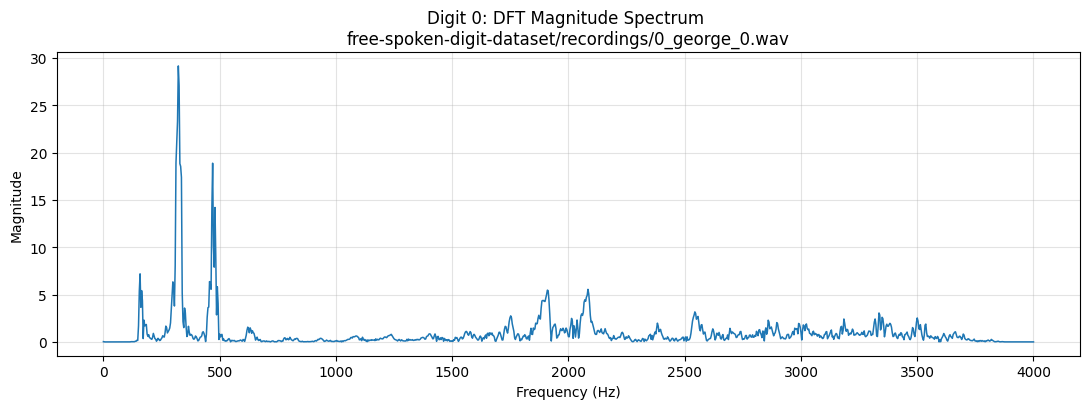

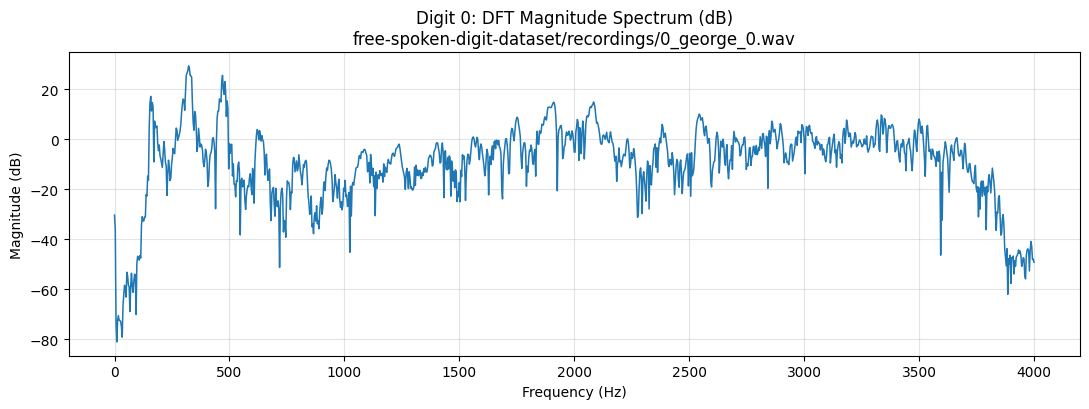

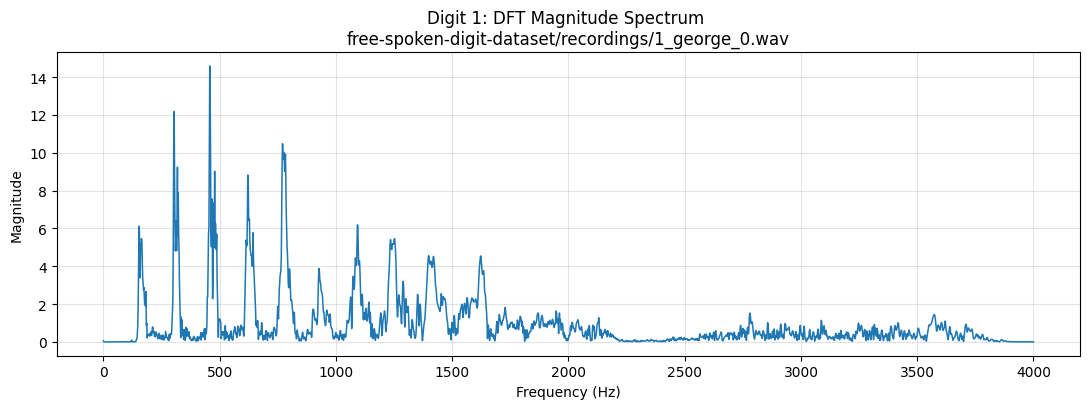

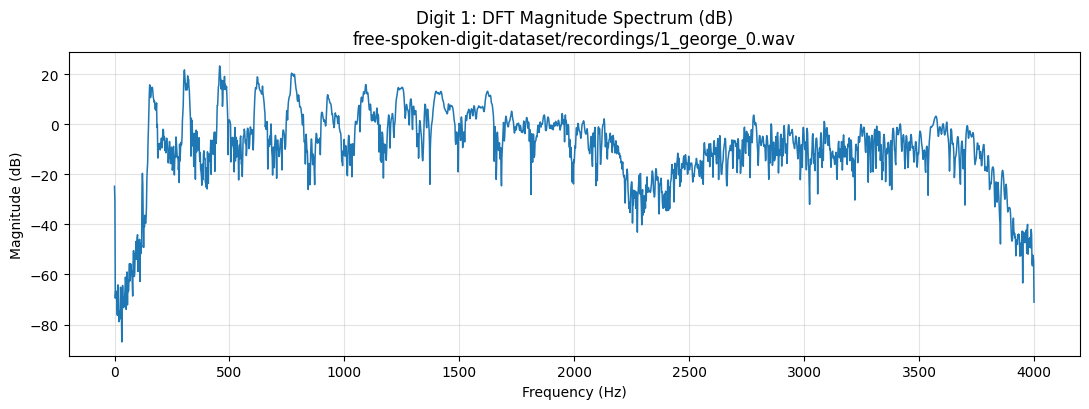

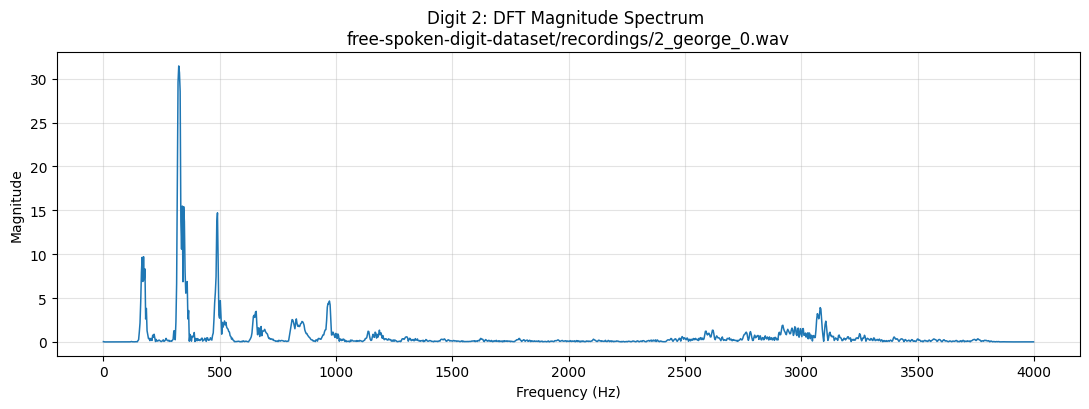

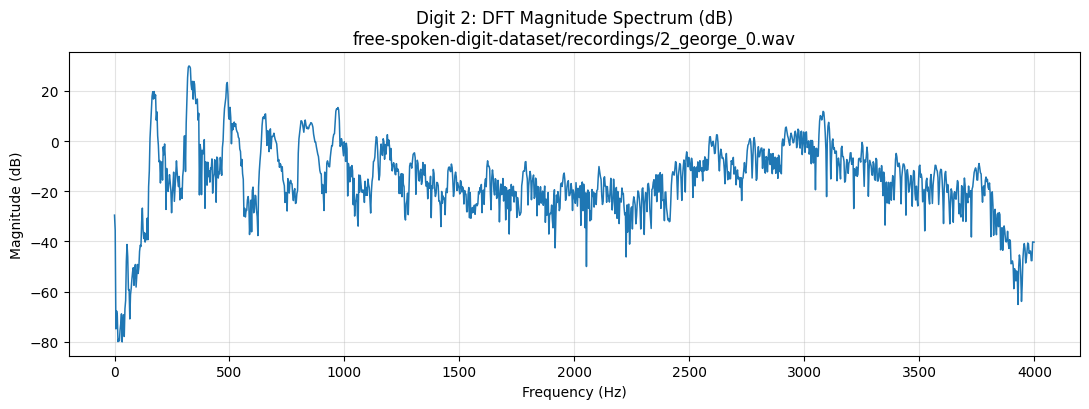

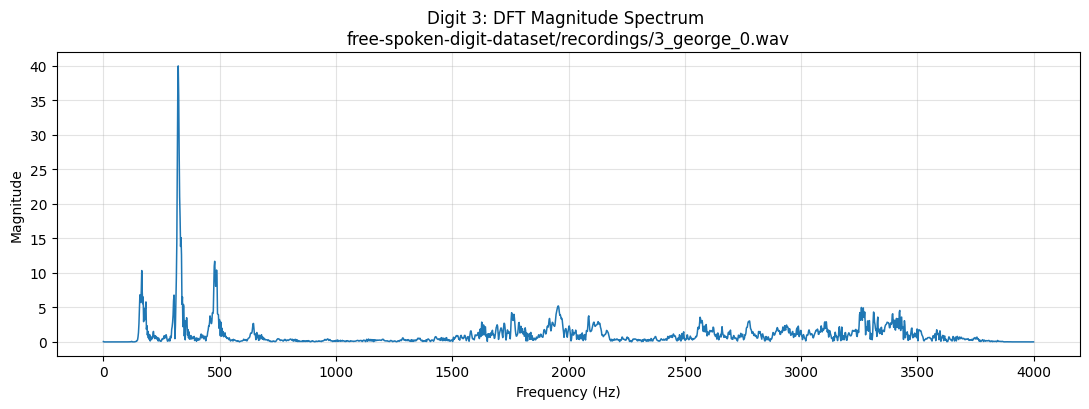

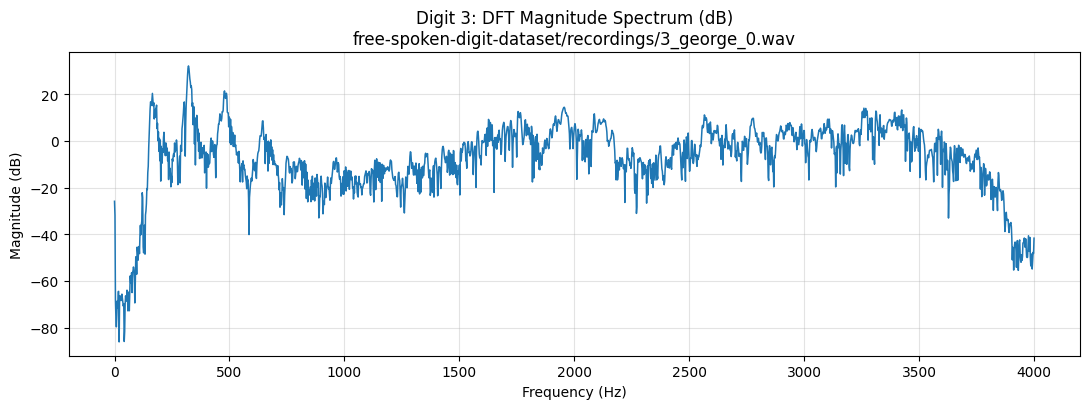

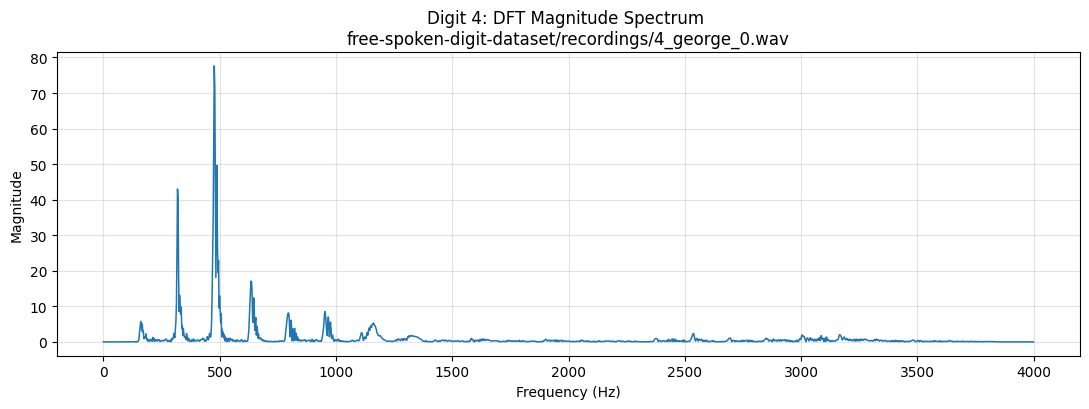

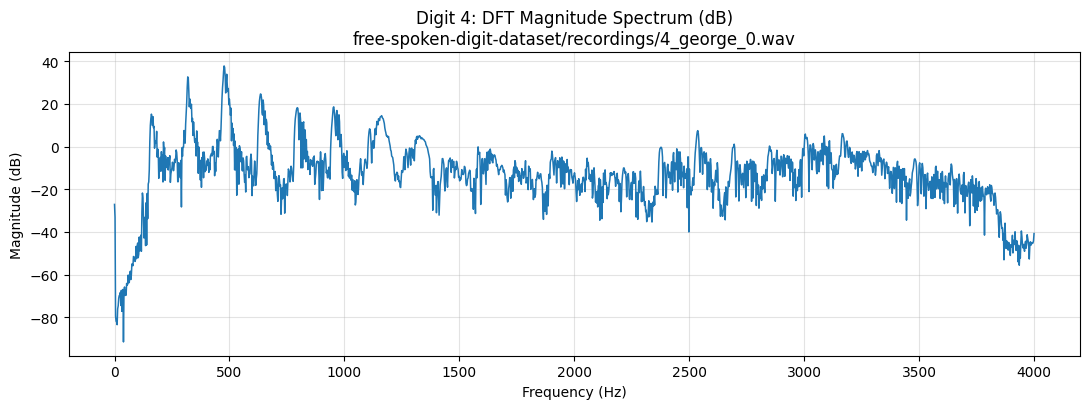

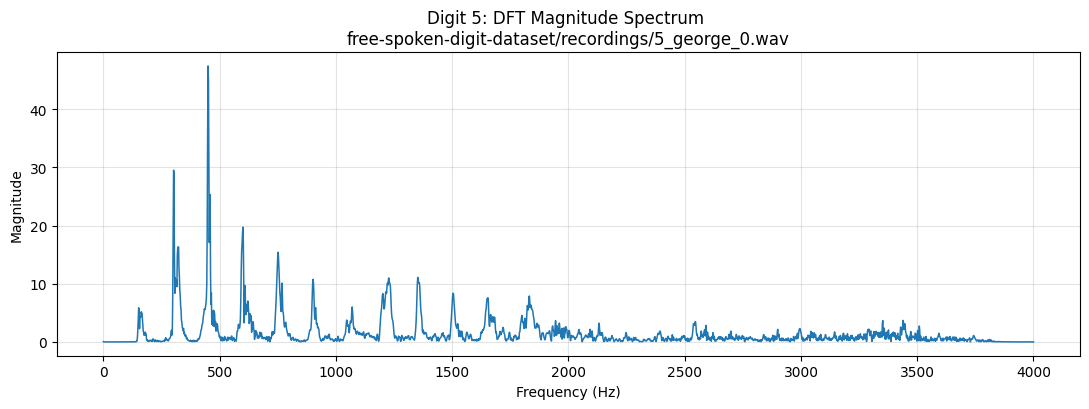

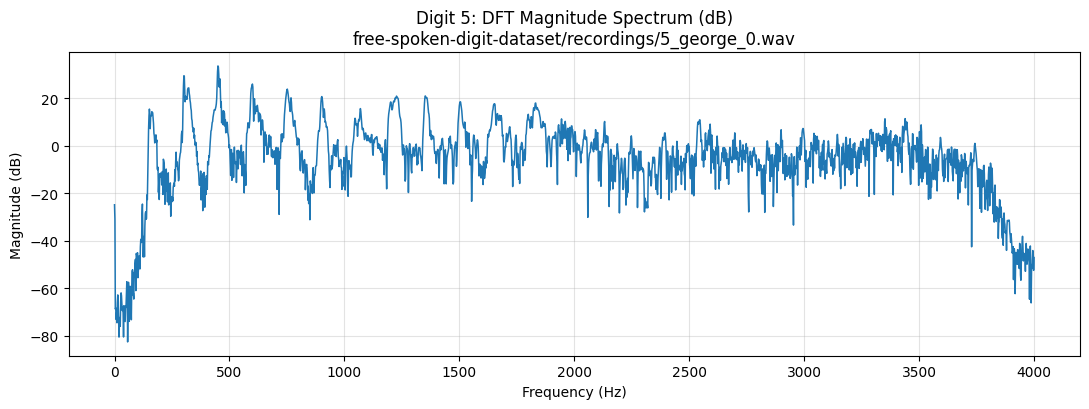

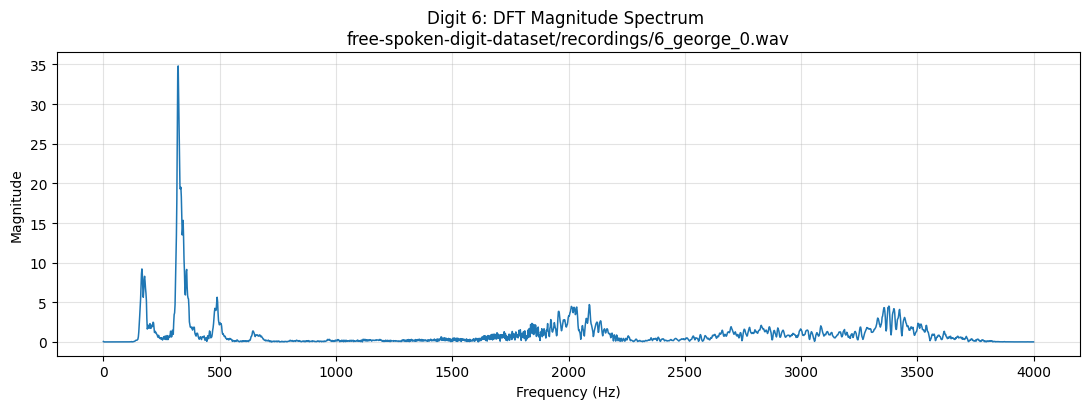

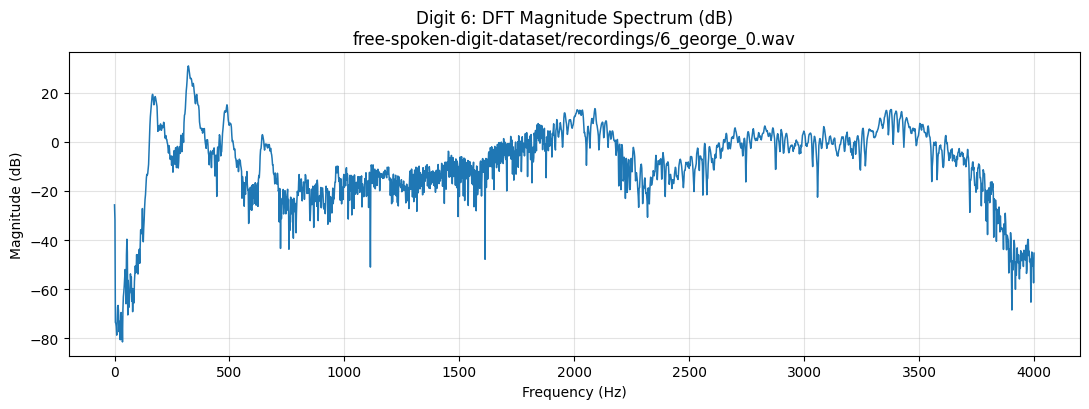

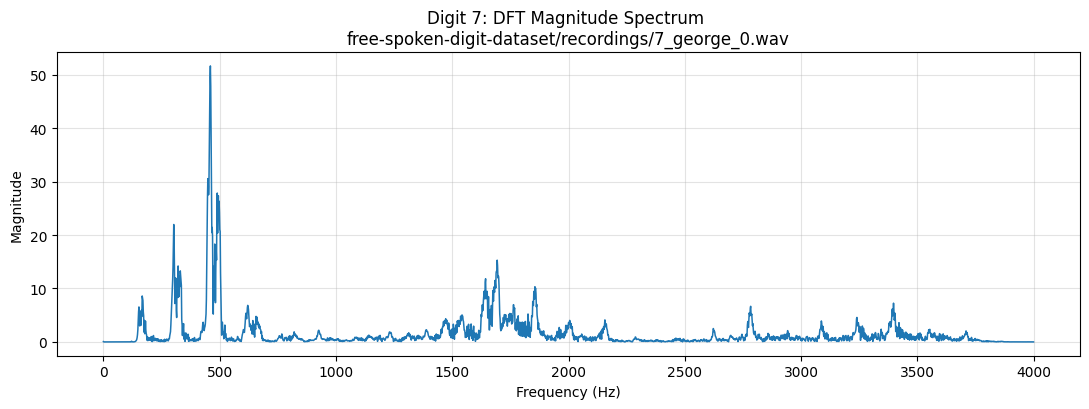

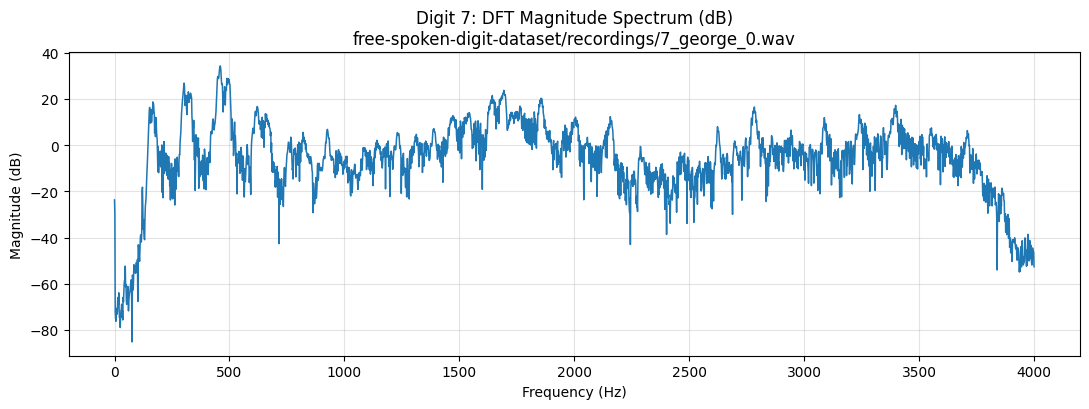

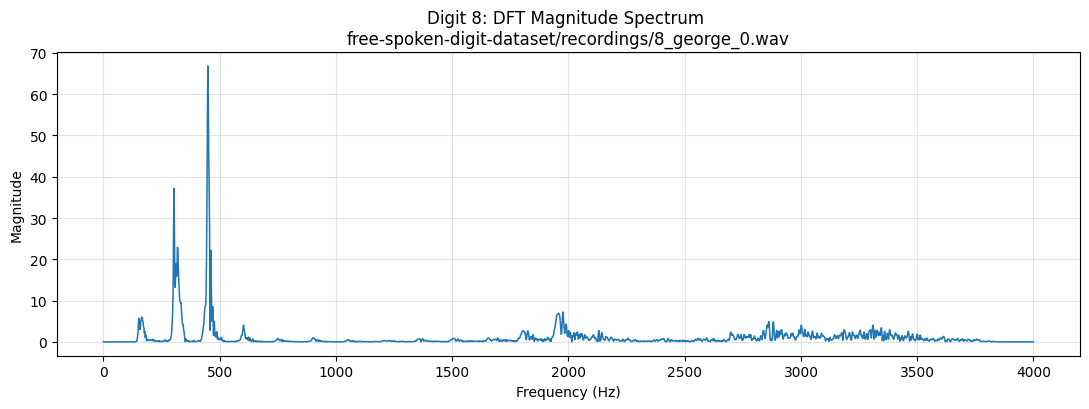

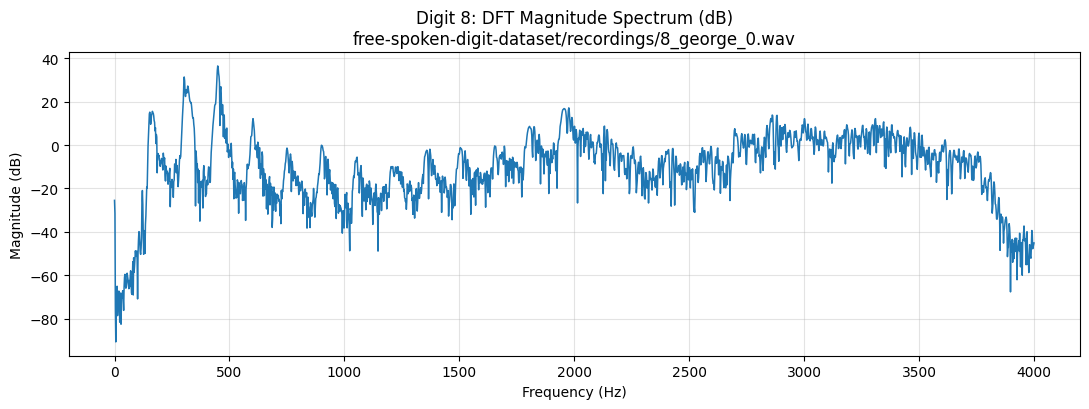

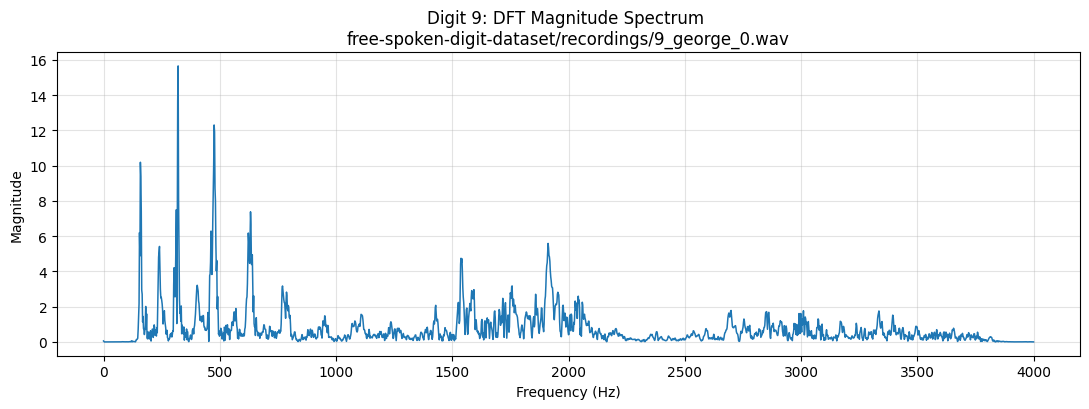

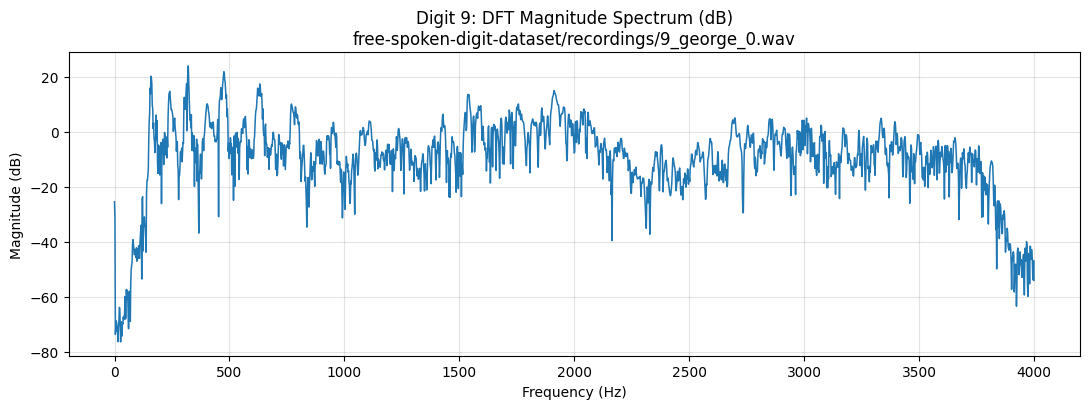

In [ ]:
for digit_label in Digits:
    if digit_label not in samples:
        continue

    speech_sig = samples[digit_label]["speech_sig"]
    fs = samples[digit_label]["fs"]
    audio_path = samples[digit_label]["path"]

    N = len(speech_sig)
    w = np.hanning(N)
    speech_sig_with_win = speech_sig * w

    X = np.fft.rfft(speech_sig_with_win)
    freqs = np.fft.rfftfreq(N, d=1.0 / fs)
    mag = np.abs(X)
    mag_db = 20 * np.log10(mag + 1e-12)
    plt.figure(figsize=(11, 4.2))
    plt.plot(freqs, mag, linewidth=1.1)
    plt.title(f"Digit {digit_label}: DFT Magnitude Spectrum \n{audio_path}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(11, 4.2))
    plt.plot(freqs, mag_db, linewidth=1.1)
    plt.title(f"Digit {digit_label}: DFT Magnitude Spectrum (dB)\n{audio_path}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()

Zero Padding

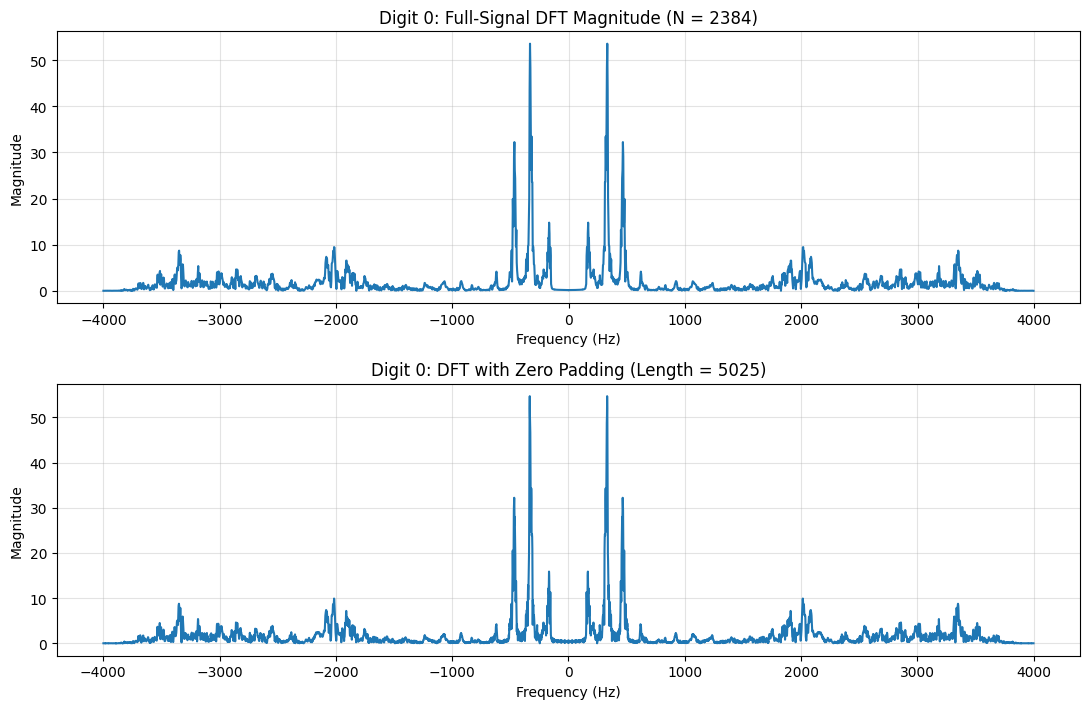

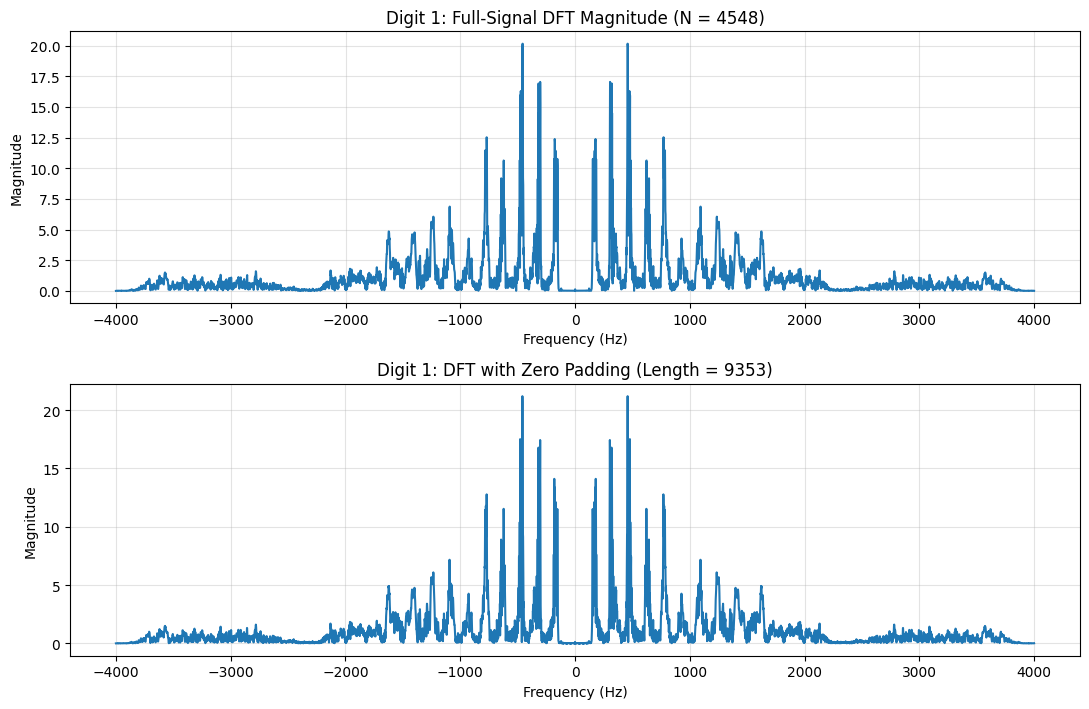

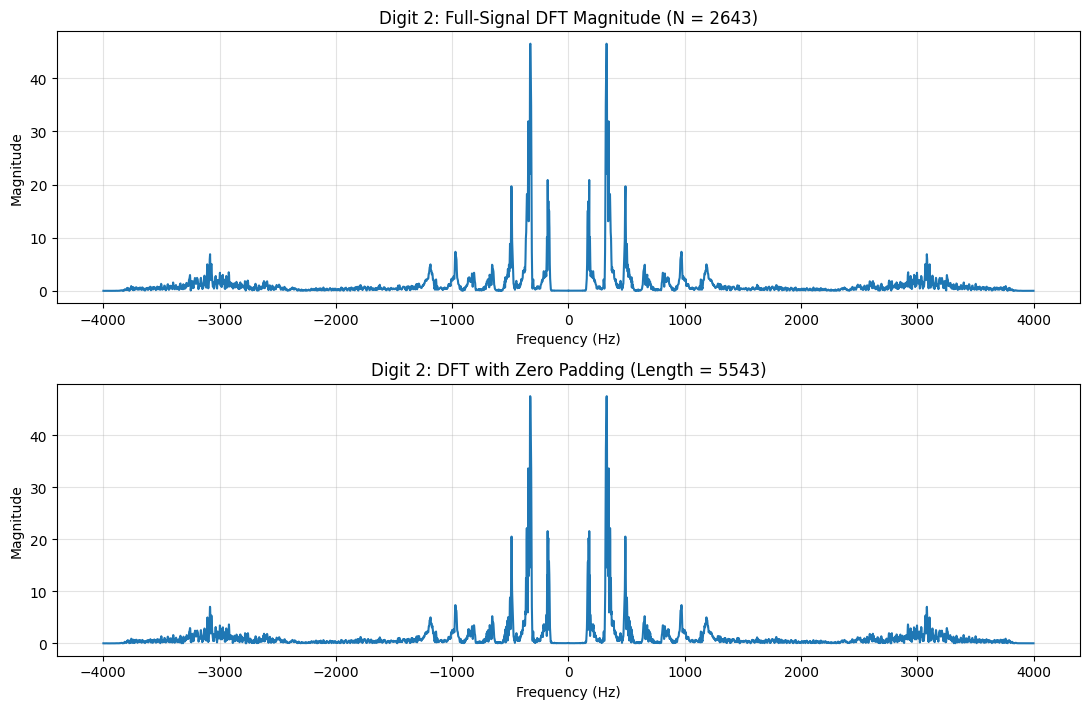

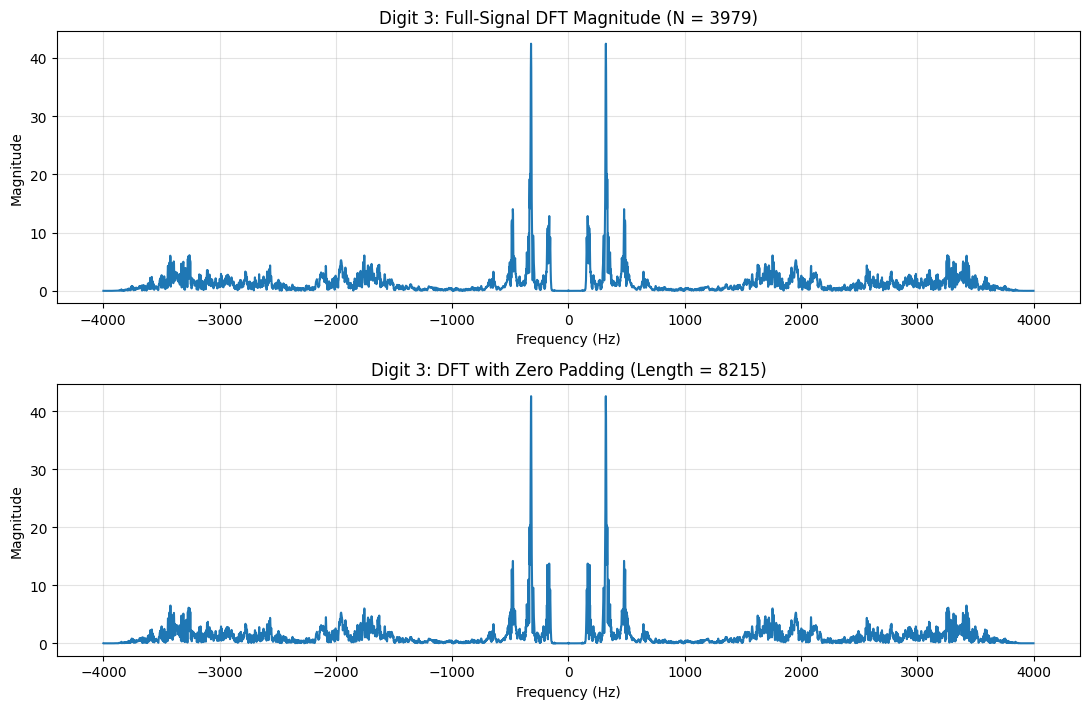

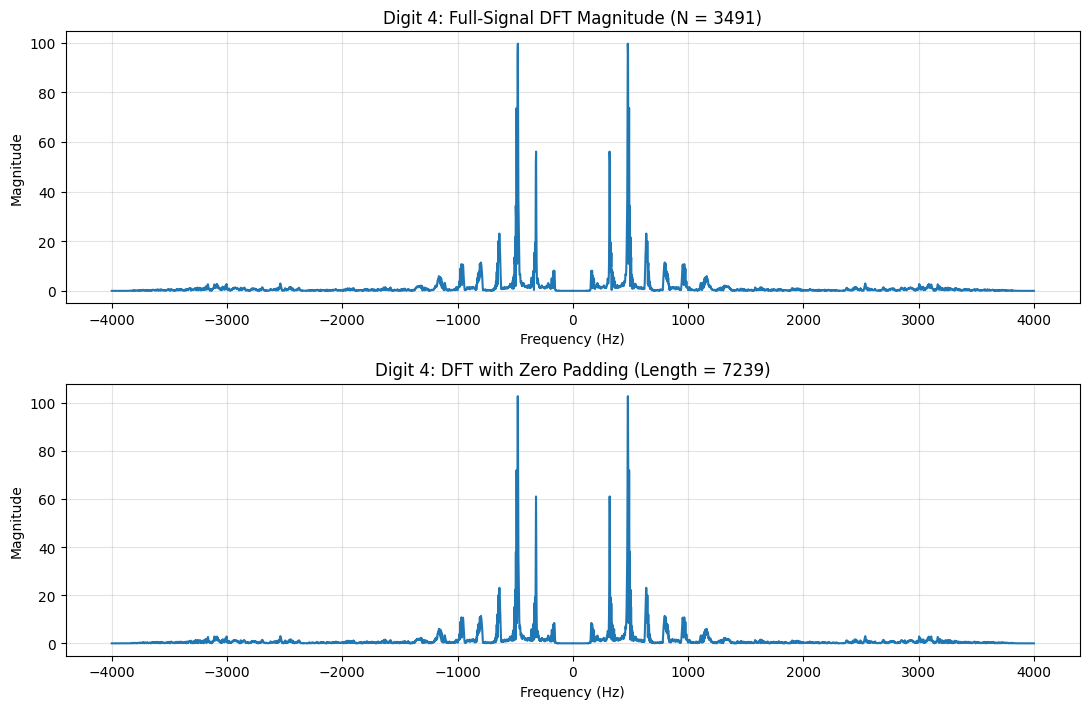

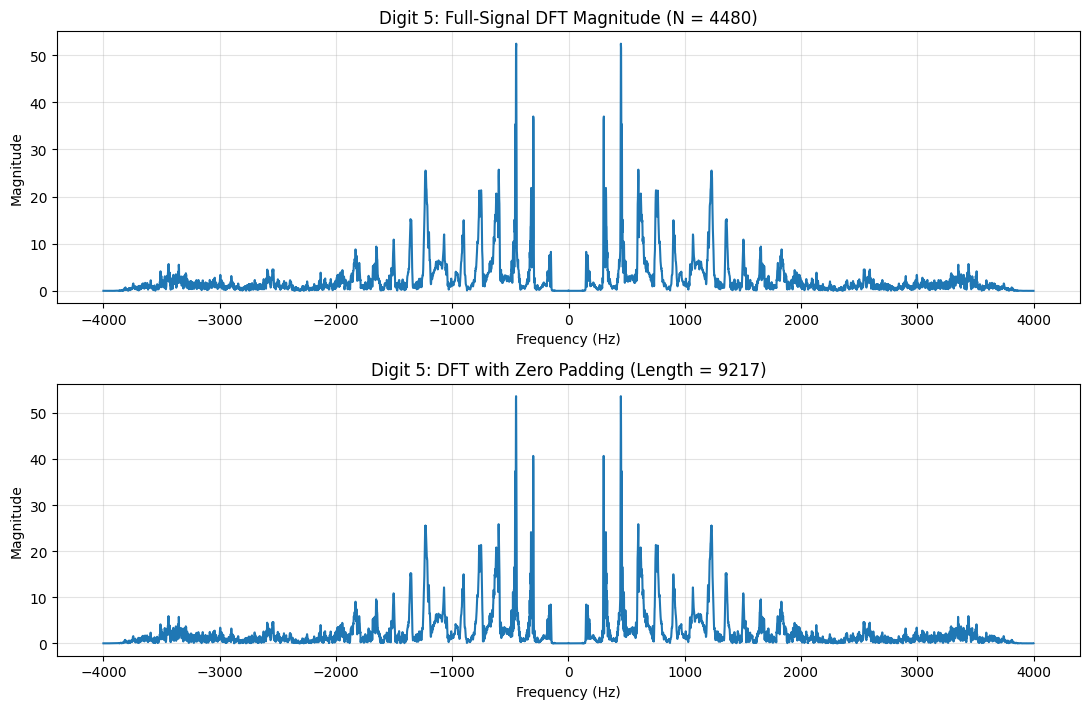

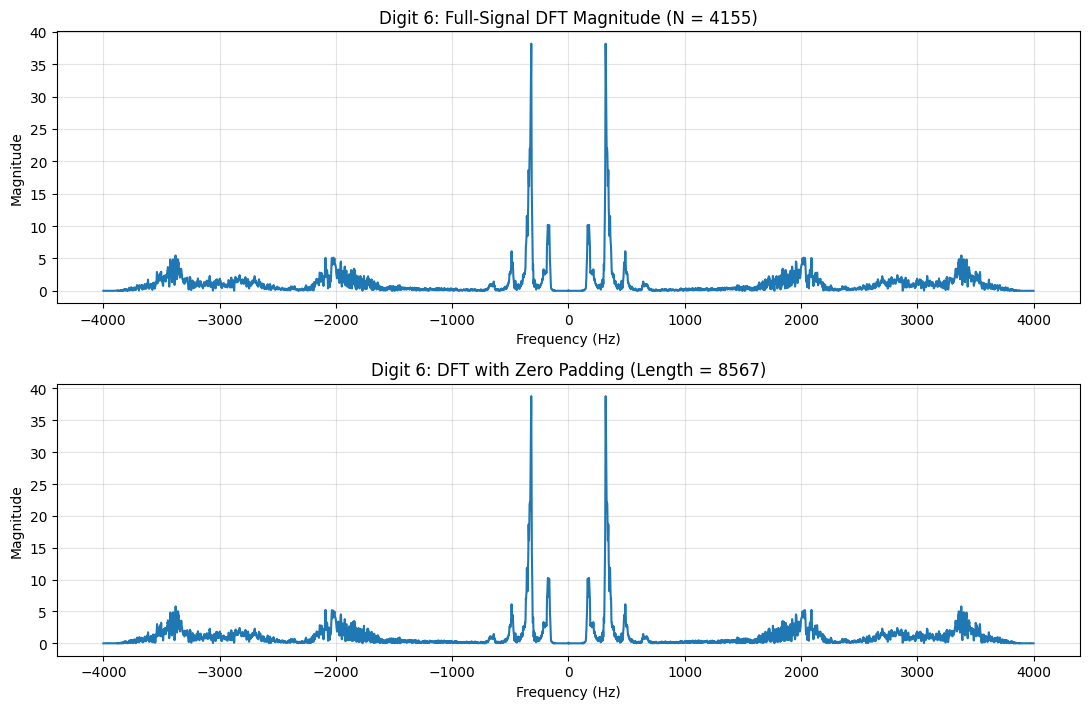

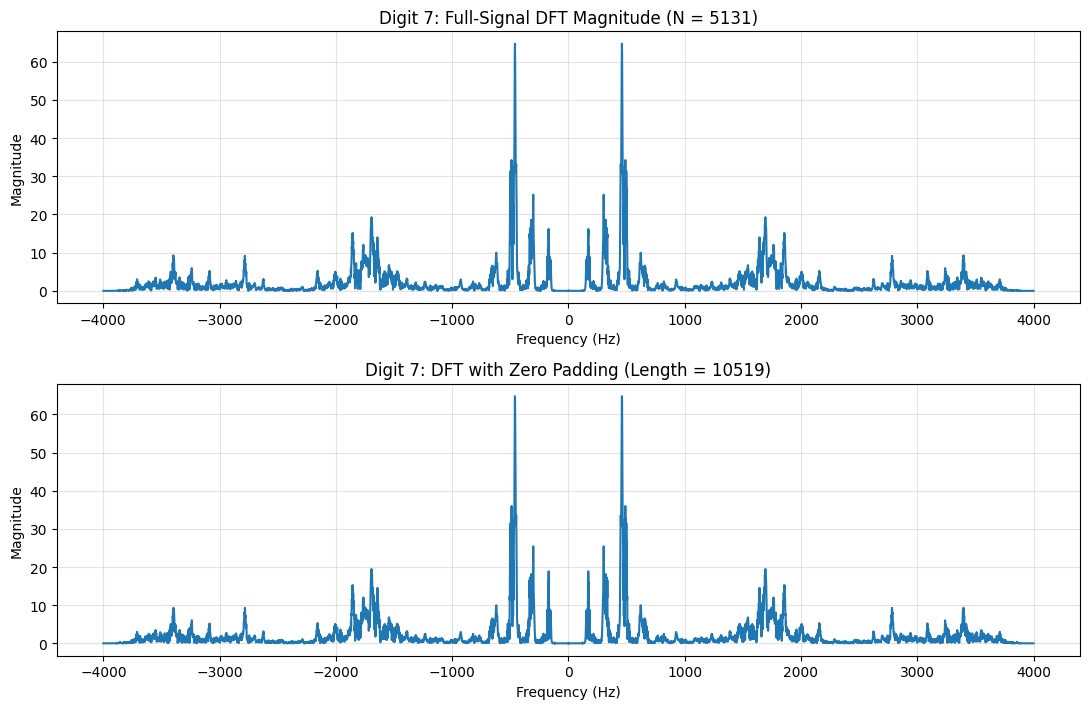

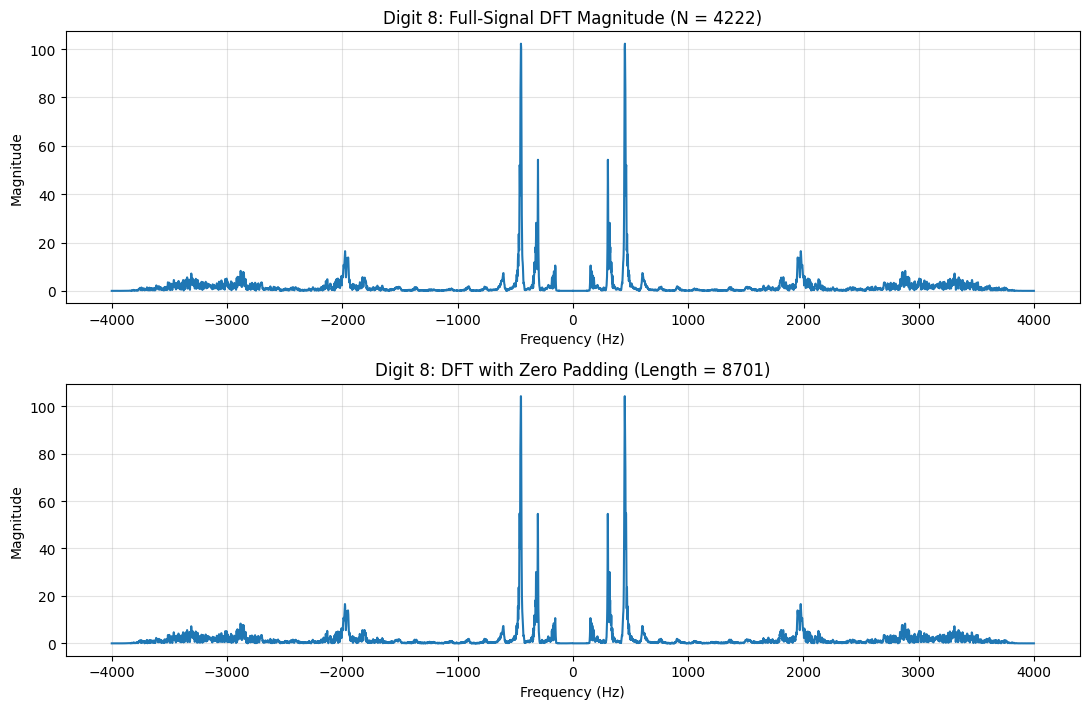

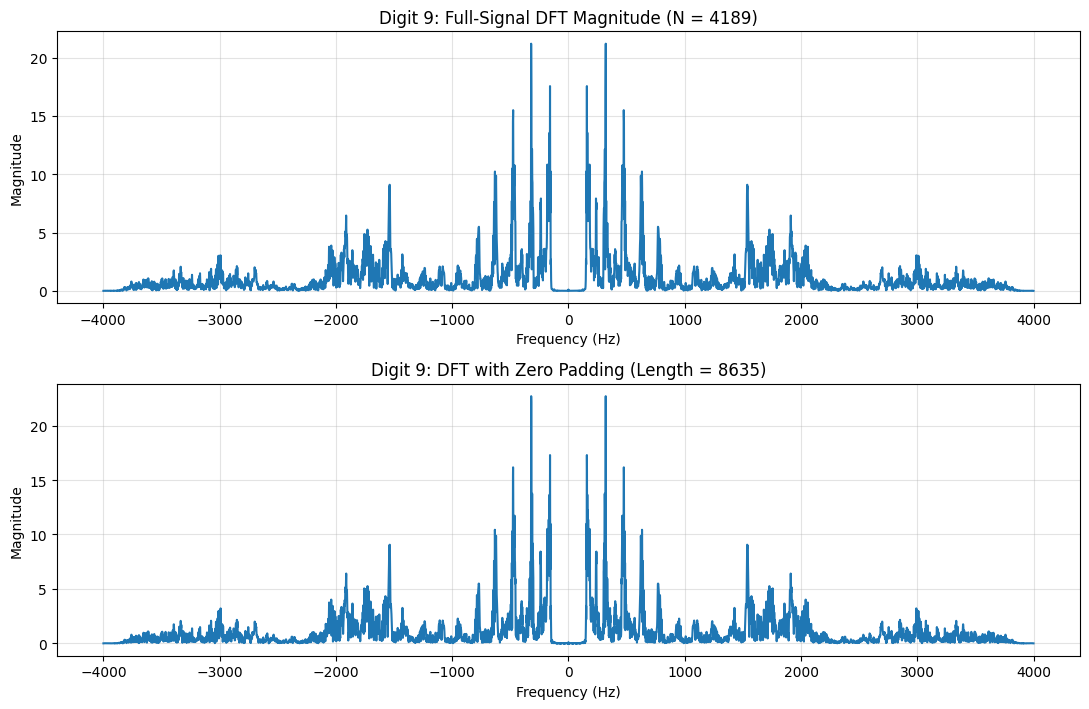

In [ ]:
zero_padding_results = {}

for digit_label in Digits:
    if digit_label not in samples:
        continue

    speech_sig = samples[digit_label]["speech_sig"]
    fs = samples[digit_label]["fs"]
    N = samples[digit_label]["N"]

    spectrum = np.fft.fft(speech_sig)
    spectrum = np.fft.fftshift(spectrum)

    freq_axis = np.fft.fftfreq(N, d=1/fs)
    freq_axis = np.fft.fftshift(freq_axis)

    magnitude = np.abs(spectrum)

    N_pad = N*2 + 257
    sig_pad = librosa.util.fix_length(speech_sig, size=N_pad)
    spec_pad = np.fft.fftshift(np.fft.fft(sig_pad))
    freq_pad = np.fft.fftshift(np.fft.fftfreq(N_pad, d=1.0 / fs))
    mag_pad = np.abs(spec_pad)

    zero_padding_results[digit_label] = {
        "frequency_axis": freq_axis,
        "magnitude": magnitude,
        "padded_frequency": freq_pad,
        "padded_magnitude": mag_pad,
        "padded_length": N_pad
    }

    plt.figure(figsize=(11, 7.2))
    plt.subplot(2, 1, 1)
    plt.plot(freq_axis, magnitude)
    plt.title(f"Digit {digit_label}: Full-Signal DFT Magnitude (N = {N})")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.35)

    plt.subplot(2, 1, 2)
    plt.plot(freq_pad, mag_pad)
    plt.title(f"Digit {digit_label}: DFT with Zero Padding (Length = {N_pad})")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.show()

Features i will be extracting

In [ ]:

rows_dft = []
feature_results = {}

feature_cols = [
    "centroid_mean",
    "bandwidth_mean",
    "rolloff85_mean",
    "rolloff95_mean",
    "flatness_mean",
    "contrast_mean"
]


DFT spectral features extraction

In [ ]:
for i in range(len(speech_signals)):
    speech_sig = speech_signals[i]
    fs = sample_rates[i]
    label = labels[i]
    reco_name = reco_names[i]


    N = len(speech_sig)
    w = np.hanning(N)
    speech_sig_with_win = speech_sig * w

    spectrum = np.fft.rfft(speech_sig_with_win)
    magnitude = np.abs(spectrum).reshape(-1, 1)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)


    spectral_centroid = librosa.feature.spectral_centroid(S=magnitude, sr=fs)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(S=magnitude, sr=fs)
    spectral_rolloff_85 = librosa.feature.spectral_rolloff(S=magnitude, sr=fs, roll_percent=0.85)
    spectral_rolloff_95 = librosa.feature.spectral_rolloff(S=magnitude, sr=fs, roll_percent=0.95)
    spectral_flatness = librosa.feature.spectral_flatness(S=magnitude)

    Fnyquist = 0.5 * fs
    contrast_fmin = 50.0
    n_bands_safe = int(np.floor(np.log2(Fnyquist / contrast_fmin)))
    if n_bands_safe < 1:
        n_bands_safe = 1
        contrast_fmin = Fnyquist / 4.0

    spectral_contrast = librosa.feature.spectral_contrast(
        S=magnitude, sr=fs, fmin=contrast_fmin, n_bands=n_bands_safe
    )
    spectral_contrast_mean = np.mean(spectral_contrast, axis=0, keepdims=True)

    feature_results[reco_name] = {
        "digit": label,
        "centroid": float(spectral_centroid[0, 0]),
        "bandwidth": float(spectral_bandwidth[0, 0]),
        "rolloff85": float(spectral_rolloff_85[0, 0]),
        "rolloff95": float(spectral_rolloff_95[0, 0]),
        "flatness": float(spectral_flatness[0, 0]),
        "contrast_mean": float(spectral_contrast_mean[0, 0])
    }

    rows_dft.append({
        "file_name": reco_name,
        "digit": label,
        "centroid_mean": float(spectral_centroid[0, 0]),
        "bandwidth_mean": float(spectral_bandwidth[0, 0]),
        "rolloff85_mean": float(spectral_rolloff_85[0, 0]),
        "rolloff95_mean": float(spectral_rolloff_95[0, 0]),
        "flatness_mean": float(spectral_flatness[0, 0]),
        "contrast_mean": float(spectral_contrast_mean[0, 0])
    })


DFT features extraction

In [ ]:
df_dft = pd.DataFrame(rows_dft)
df_dft.head()


,file_name,digit,centroid_mean,bandwidth_mean,rolloff85_mean,rolloff95_mean,flatness_mean,contrast_mean
0,0_george_0.wav,0,1653.755672,1157.550778,3100.671141,3473.154362,0.019376,25.435067
1,0_george_1.wav,0,1312.894288,1008.328269,2640.710961,3311.045281,0.025056,28.727610
2,0_george_10.wav,0,1568.242604,1133.769524,3121.852971,3417.254112,0.012586,27.310055
3,0_george_11.wav,0,1462.021633,1070.686327,2909.289617,3403.278689,0.014442,27.989314
4,0_george_12.wav,0,1407.497388,1020.808272,2658.765432,3308.641975,0.016918,25.982944


Spectral feature plots

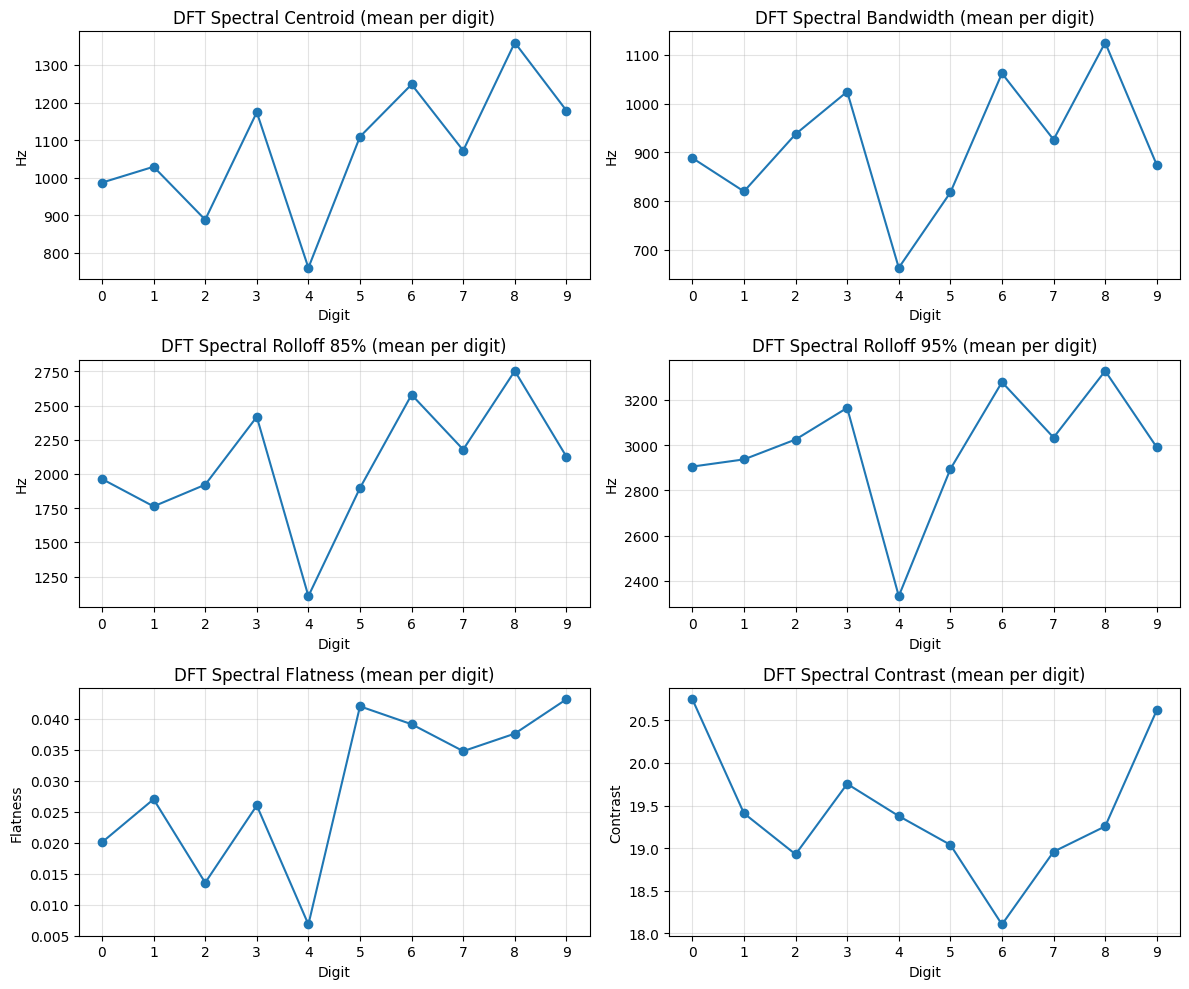

In [ ]:
digit_summary_dft = df_dft.groupby("digit").mean(numeric_only=True).reset_index()

plt.figure(figsize=(12, 10))

plt.subplot(3, 2, 1)
plt.plot(digit_summary_dft["digit"], digit_summary_dft["centroid_mean"], "-o")
plt.title("DFT Spectral Centroid (mean per digit)")
plt.xlabel("Digit")
plt.ylabel("Hz")
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 2)
plt.plot(digit_summary_dft["digit"], digit_summary_dft["bandwidth_mean"], "-o")
plt.title("DFT Spectral Bandwidth (mean per digit)")
plt.xlabel("Digit")
plt.ylabel("Hz")
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 3)
plt.plot(digit_summary_dft["digit"], digit_summary_dft["rolloff85_mean"], "-o")
plt.title("DFT Spectral Rolloff 85% (mean per digit)")
plt.xlabel("Digit")
plt.ylabel("Hz")
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 4)
plt.plot(digit_summary_dft["digit"], digit_summary_dft["rolloff95_mean"], "-o")
plt.title("DFT Spectral Rolloff 95% (mean per digit)")
plt.xlabel("Digit")
plt.ylabel("Hz")
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 5)
plt.plot(digit_summary_dft["digit"], digit_summary_dft["flatness_mean"], "-o")
plt.title("DFT Spectral Flatness (mean per digit)")
plt.xlabel("Digit")
plt.ylabel("Flatness")
plt.grid(True, alpha=0.35)

plt.subplot(3, 2, 6)
plt.plot(digit_summary_dft["digit"], digit_summary_dft["contrast_mean"], "-o")
plt.title("DFT Spectral Contrast (mean per digit)")
plt.xlabel("Digit")
plt.ylabel("Contrast")
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()





---



## 4- STFT Analysis



---



## 5- Wavelet Analysis

## 6- Featrue Classification